# Insurance claim amount prediction

# Import libraries

In [3]:
# Import Libraries
import pandas as pd
from ydata_profiling import ProfileReport
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import math

# Load the generated Dataset

In [4]:
df = pd.read_csv("insurance_dataset_corr.csv")

In [5]:
df.head(5)

,Policy_number,Type,Coverage,Coverage_Add_Ons,Policy_Status,Validity,Insured_amount,Premium_amount,Issuance_date,Policy_holder_name,...,Driver_history,Driving_experience,Previous_traffic_violations,License_expiry_date,Driver_address,Driver_contact_details,Driver_medical_history,Alcohol_drug_test_results,License_class_if_applicable,License_Type
0,POL91142091,Car Insurance,Comprehensive,Road side assistance (24*7),Suspended,2024-12-12 to 2025-08-22,1788284,68210,2025-03-10,Karen Walsh,...,Clean driving record,6,1 parking violation,2025-05-25,846 Brittany Trail Suite 526\nWest Richardshir...,"+1-968-219-7322, ggoodwin@example.net",Hypertension,Passed,HGV,Permanent
1,POL99025488,Car Insurance,Third Party,No Claim Bonus,Cancelled,2024-04-04 to 2025-11-17,1268543,38634,2024-07-07,Amanda Carter DDS,...,Clean driving record,1,1 speeding,2027-01-28,"82136 Hughes Turnpike\nLaurieport, MT 16282","(793)957-4631x775, joseph74@example.com",Asthma,Passed,LMV,Learning
2,POL23635842,Car Insurance,Accidental Coverage,Road side assistance (24*7),Effective,2025-02-06 to 2026-02-04,660740,18084,2024-06-17,Jessica Ray,...,One speeding ticket,15,1 speeding,2029-09-13,"45921 Travis Station\nScottport, NV 50984","339-322-7271x71602, petersjessica@example.com",Diabetes,Failed,HGV,Learning
3,POL67645878,Car Insurance,Accidental Coverage,No Claim Bonus,Effective,2025-02-19 to 2026-02-14,1073115,41030,2024-06-15,Michelle Riley,...,One traffic violation,11,1 parking violation,2025-05-26,"40595 Butler Square Suite 784\nGraystad, MO 88166","2578130598, karen37@example.com",No major medical issues,Failed,LMV,Learning
4,POL63547538,Car Insurance,Comprehensive,Road side assistance (24*7),Cancelled,2025-02-09 to 2025-12-18,592923,9148,2024-08-22,Meghan Taylor,...,2 minor accidents,11,1 parking violation,2026-09-20,"09138 Allen Shores\nSouth Marco, AS 60302","650-431-9774x882, kathryn58@example.com",No major medical issues,Failed,LMV,Learning


In [6]:
attribute_names = df.columns.tolist()
print(attribute_names)

['Policy_number', 'Type', 'Coverage', 'Coverage_Add_Ons', 'Policy_Status', 'Validity', 'Insured_amount', 'Premium_amount', 'Issuance_date', 'Policy_holder_name', 'Payment_status', 'Payment_Frequency', 'Policy_renewal_date', 'Claimant_name', 'Relationship', 'Address', 'Claimant_occupation', 'Claimant_age', 'Marital_status', 'Claimant_driver_history', 'Emergency_contact_information', 'Phone_Number', 'Email', 'Registration_number', 'Make', 'Model', 'Year', 'Engine_Chassis_number', 'Color', 'Vehicle_condition', 'Vehicle_value_market_value', 'Vehicle_type_sedan_SUV_etc', 'Vehicle_history_accident_repair_history', 'Fuel_type', 'Insurance_coverage_type', 'Odometer_reading', 'Vehicle_safety_features', 'Date', 'Time', 'Location', 'Nature_of_incident', 'Police_report', 'Incident_severity_level', 'Weather_conditions_at_the_time_of_the_accident', 'Witnesses', 'Traffic_condition_at_the_time_of_incident', 'Incident_description', 'Involvement_of_pedestrians_or_animals', 'Cause_of_incident', 'Damage_t

# EDA - Exploratory Data Analysis

In [7]:
# Number of attributes and records in the dataset
df.shape

(5000, 114)

# Data Preprocessing 

Step1 - Drop nominal attributes

In [8]:
df = df.drop(['Policy_holder_name'], axis=1)
df = df.drop(['Claimant_name'], axis=1)
df = df.drop(['Relationship'], axis=1)
df = df.drop(['Address'], axis=1)
df = df.drop(['Claimant_occupation'], axis=1)
df = df.drop(['Marital_status'], axis=1)
df = df.drop(['Emergency_contact_information'], axis=1)
df = df.drop(['Phone_Number'], axis=1)
df = df.drop(['Email'], axis=1)
df = df.drop(['Registration_number'], axis=1)
df = df.drop(['Make'], axis=1)
df = df.drop(['Model'], axis=1)
df = df.drop(['Year'], axis=1)
df = df.drop(['Engine_Chassis_number'], axis=1)
df = df.drop(['Color'], axis=1)
df = df.drop(['Date'], axis=1)
df = df.drop(['Police_report'], axis=1)
df = df.drop(['Time'], axis=1)
df = df.drop(['Witnesses'], axis=1)
df = df.drop(['Accident_scene_photos_videos'], axis=1)
df = df.drop(['Surveyor_report'], axis=1)
df = df.drop(['Total_Loss_Evaluation'], axis=1)
df = df.drop(['Repair_shop_details'], axis=1)
df = df.drop(['Claim_Form'], axis=1)
df = df.drop(['FIR'], axis=1)
df = df.drop(['Repair_estimate_bill'], axis=1)
df = df.drop(['Supporting_documents'], axis=1)
df = df.drop(['Payment_details'], axis=1)
df = df.drop(['Claim_history_report'], axis=1)
df = df.drop(['Injury_details'], axis=1)
df = df.drop(['Medical_bills'], axis=1)
df = df.drop(['Hospitalization_details'], axis=1)
df = df.drop(['Treatment_type'], axis=1)
df = df.drop(['Medical_reports'], axis=1)
df = df.drop(['Doctor_statement'], axis=1)
df = df.drop(['Prescription_details'], axis=1)
df = df.drop(['Physiotherapy_details'], axis=1)
df = df.drop(['Compliance_check_list'], axis=1)
df = df.drop(['Legal_obligations_if_any'], axis=1)
df = df.drop(['Forensic_examination_if_any'], axis=1)
df = df.drop(['Claims_audit_findings'], axis=1)
df = df.drop(['Claim_review_history'], axis=1)
df = df.drop(['Internal_audit_report'], axis=1)
df = df.drop(['Supervisor_Manager_approval'], axis=1)
df = df.drop(['Driver_address'], axis=1)
df = df.drop(['Driver_contact_details'], axis=1)
df = df.drop(['Driver_medical_history'], axis=1)
df = df.drop(['Driver_license'], axis=1)
df = df.drop(['Policy_number'], axis=1)
df = df.drop(['Location'], axis=1)
df = df.drop(['RC_Book'], axis=1)
df = df.drop(['Issuance_date'], axis=1)
df = df.drop(['Claimant_driver_history'], axis=1)
df = df.drop(['Vehicle_history_accident_repair_history'], axis=1)
df = df.drop(['Vehicle_safety_features'], axis=1)
df = df.drop(['Incident_severity_level'], axis=1)

In [9]:
df.shape

(5000, 58)

Dropped irrelevent attributes from the dataset that are not useful for generating the correlation of claim amount

Step2 - Check the datatype for the attributes

In [10]:
df.dtypes

Type                                               object
Coverage                                           object
Coverage_Add_Ons                                   object
Policy_Status                                      object
Validity                                           object
Insured_amount                                      int64
Premium_amount                                      int64
Payment_status                                     object
Payment_Frequency                                  object
Policy_renewal_date                                object
Claimant_age                                        int64
Vehicle_condition                                  object
Vehicle_value_market_value                        float64
Vehicle_type_sedan_SUV_etc                         object
Fuel_type                                          object
Insurance_coverage_type                            object
Odometer_reading                                    int64
Nature_of_inci

Step3: Check for any duplicate data

In [11]:
#Duplicate Data
# Find duplicate rows based on all columns
duplicate_rows = df[df.duplicated(keep='last')]

# To see the results
duplicate_rows

,Type,Coverage,Coverage_Add_Ons,Policy_Status,Validity,Insured_amount,Premium_amount,Payment_status,Payment_Frequency,Policy_renewal_date,...,Final_settlement_approval,Claim_verification,Fraud_detection_approval,Driver_history,Driving_experience,Previous_traffic_violations,License_expiry_date,Alcohol_drug_test_results,License_class_if_applicable,License_Type


Step4: Check for any missing data

In [12]:
#Check for the count of missing data in each attribute
df.isnull().sum()

Type                                              0
Coverage                                          0
Coverage_Add_Ons                                  0
Policy_Status                                     0
Validity                                          0
Insured_amount                                    0
Premium_amount                                    0
Payment_status                                    0
Payment_Frequency                                 0
Policy_renewal_date                               0
Claimant_age                                      0
Vehicle_condition                                 0
Vehicle_value_market_value                        0
Vehicle_type_sedan_SUV_etc                        0
Fuel_type                                         0
Insurance_coverage_type                           0
Odometer_reading                                  0
Nature_of_incident                                0
Weather_conditions_at_the_time_of_the_accident    0
Traffic_cond

# Check for Data Inconsisteny

Step5: Outlier Analysis for Numerical attributes using Box Plot analysis

In [13]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_cols)

Index(['Insured_amount', 'Premium_amount', 'Claimant_age',
       'Vehicle_value_market_value', 'Odometer_reading', 'Extent_of_damage',
       'Repair_estimates', 'Repair_Cost', 'Depreciation', 'Salvage_value',
       'Insurance_settlement_amount', 'Repair_duration', 'Claim_amount',
       'Deductibles', 'Previous_claims', 'Loss_of_wages',
       'Driving_experience'],
      dtype='object')


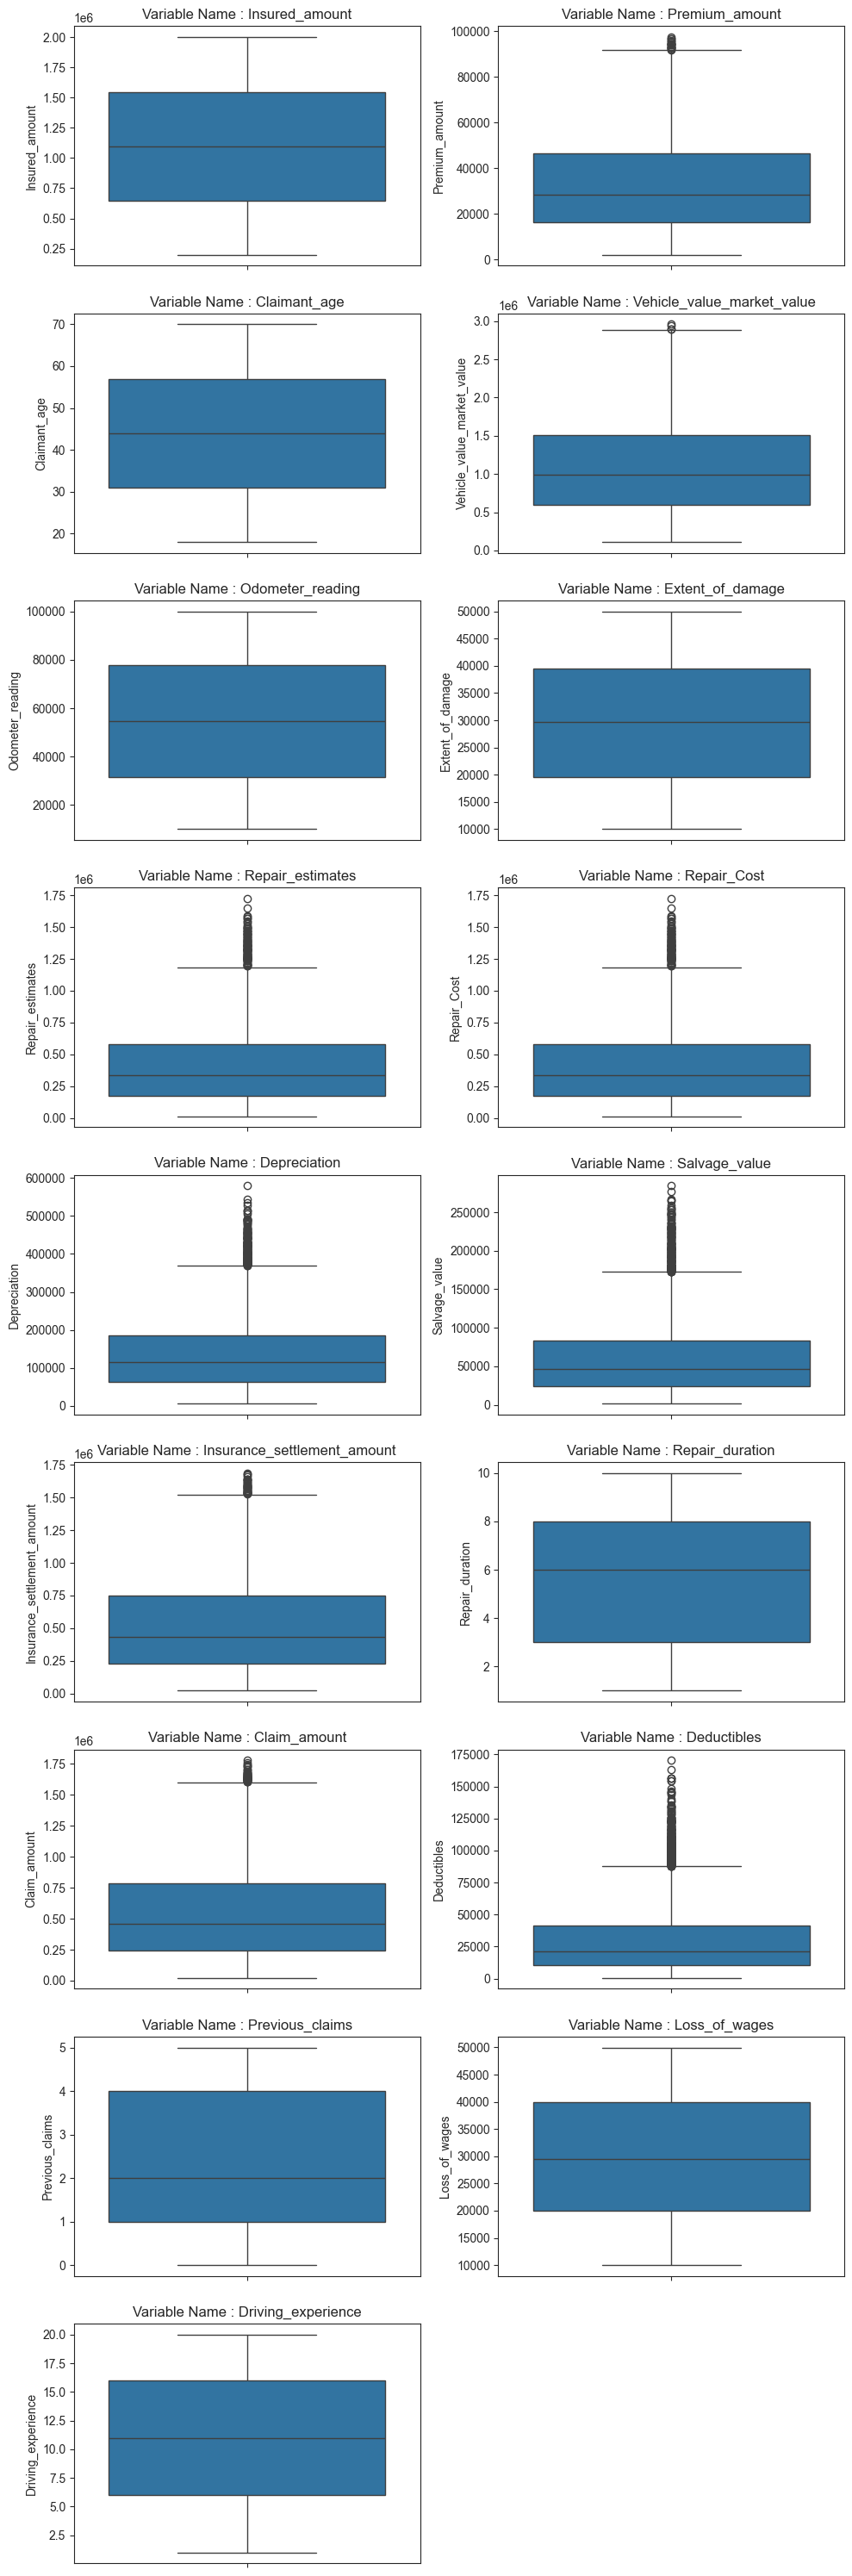

In [14]:

#list1 = ["Insured_amount", "Premium_amount", "Claim_amount", "Deductibles", "Vehicle_value_market_value", "Repair_estimates", "Depreciation", "Salvage_value", "Insurance_settlement_amount"]
df_new = df[numerical_cols]
# Boxplot
sns.set_style("ticks") 
  

cols = df_new.columns
  
# Plot build for each variable 
plt.figure(figsize=(10, 30) )
for count, item in enumerate(cols, 1): 
    plt.subplot(9, 2, count) 
    sns.boxplot(df_new[item])
    plt.title(f"Variable Name : {item}")

plt.tight_layout() 
plt.show() 

Features with outliers based on above Box Plot analyis - 'Premium_amount', 'Vehicle_value_market_value', 'Repair_estimates', 'Repair_Cost', 'Depreciation', 'Salvage_value', 'Insurance_settlement_amount''Claim_amount', 'Deductibles'. 

In [15]:
# List of numerical attributes with outliers
numerical_columns = ['Premium_amount', 'Vehicle_value_market_value', 'Repair_estimates', 'Repair_Cost', 'Depreciation', 'Salvage_value', 'Insurance_settlement_amount','Claim_amount', 'Deductibles']

def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

# Remove outliers
df_cleaned = remove_outliers(df, numerical_columns)

# Print the cleaned DataFrame
print(df_cleaned.describe())
# Export the cleaned DataFrame to a CSV file
#df_cleaned.to_csv('insurance_dataset_cleaned.csv', index=False)

       Insured_amount  Premium_amount  Claimant_age  \
count    4.346000e+03     4346.000000    4346.00000   
mean     1.004248e+06    30340.959733      43.88081   
std      4.849714e+05    19335.972721      15.19109   
min      2.001080e+05     2143.000000      18.00000   
25%      5.865832e+05    14909.250000      31.00000   
50%      9.869465e+05    25802.500000      44.00000   
75%      1.393597e+06    42690.250000      57.00000   
max      1.999703e+06    91753.000000      70.00000   

       Vehicle_value_market_value  Odometer_reading  Extent_of_damage  \
count                4.346000e+03       4346.000000       4346.000000   
mean                 9.766470e+05      54718.543488      29746.893925   
std                  5.415278e+05      26047.139761      11509.283658   
min                  1.110929e+05      10025.000000      10006.000000   
25%                  5.450922e+05      31711.750000      19692.250000   
50%                  8.949684e+05      54421.500000      29684.500

In [16]:
df_cleaned.head(5)

,Type,Coverage,Coverage_Add_Ons,Policy_Status,Validity,Insured_amount,Premium_amount,Payment_status,Payment_Frequency,Policy_renewal_date,...,Final_settlement_approval,Claim_verification,Fraud_detection_approval,Driver_history,Driving_experience,Previous_traffic_violations,License_expiry_date,Alcohol_drug_test_results,License_class_if_applicable,License_Type
0,Car Insurance,Comprehensive,Road side assistance (24*7),Suspended,2024-12-12 to 2025-08-22,1788284,68210,Paid,Recurring,2025-12-20,...,True,True,True,Clean driving record,6,1 parking violation,2025-05-25,Passed,HGV,Permanent
1,Car Insurance,Third Party,No Claim Bonus,Cancelled,2024-04-04 to 2025-11-17,1268543,38634,Pending,Half Yearly,2025-12-09,...,False,True,False,Clean driving record,1,1 speeding,2027-01-28,Passed,LMV,Learning
2,Car Insurance,Accidental Coverage,Road side assistance (24*7),Effective,2025-02-06 to 2026-02-04,660740,18084,Paid,Yearly,2025-07-27,...,True,True,False,One speeding ticket,15,1 speeding,2029-09-13,Failed,HGV,Learning
3,Car Insurance,Accidental Coverage,No Claim Bonus,Effective,2025-02-19 to 2026-02-14,1073115,41030,Paid,Quarterly,2026-06-19,...,True,False,True,One traffic violation,11,1 parking violation,2025-05-26,Failed,LMV,Learning
4,Car Insurance,Comprehensive,Road side assistance (24*7),Cancelled,2025-02-09 to 2025-12-18,592923,9148,Pending,Quarterly,2026-03-23,...,False,False,True,2 minor accidents,11,1 parking violation,2026-09-20,Failed,LMV,Learning


In [17]:
df_cleaned.shape

(4346, 58)

In [18]:
df_cleaned['Validity']

0       2024-12-12 to 2025-08-22
1       2024-04-04 to 2025-11-17
2       2025-02-06 to 2026-02-04
3       2025-02-19 to 2026-02-14
4       2025-02-09 to 2025-12-18
                  ...           
4995    2024-05-28 to 2026-01-09
4996    2024-04-14 to 2025-07-15
4997    2025-02-04 to 2025-11-04
4998    2024-08-13 to 2026-02-18
4999    2024-03-29 to 2025-12-27
Name: Validity, Length: 4346, dtype: object

# Data Transformation

Standardize the data: Standardization is the process of transforming data into a common format which you to make the meaningful comparison.

# Univariate Analysis - Histogram Plot (For visualizing the distribution of numerical data in DataFrame)

Input variables : Index(['Insured_amount', 'Premium_amount', 'Claimant_age',
       'Vehicle_value_market_value', 'Odometer_reading', 'Extent_of_damage',
       'Repair_estimates', 'Repair_Cost', 'Depreciation', 'Salvage_value',
       'Insurance_settlement_amount', 'Repair_duration', 'Claim_amount',
       'Deductibles', 'Previous_claims', 'Loss_of_wages',
       'Driving_experience'],
      dtype='object')


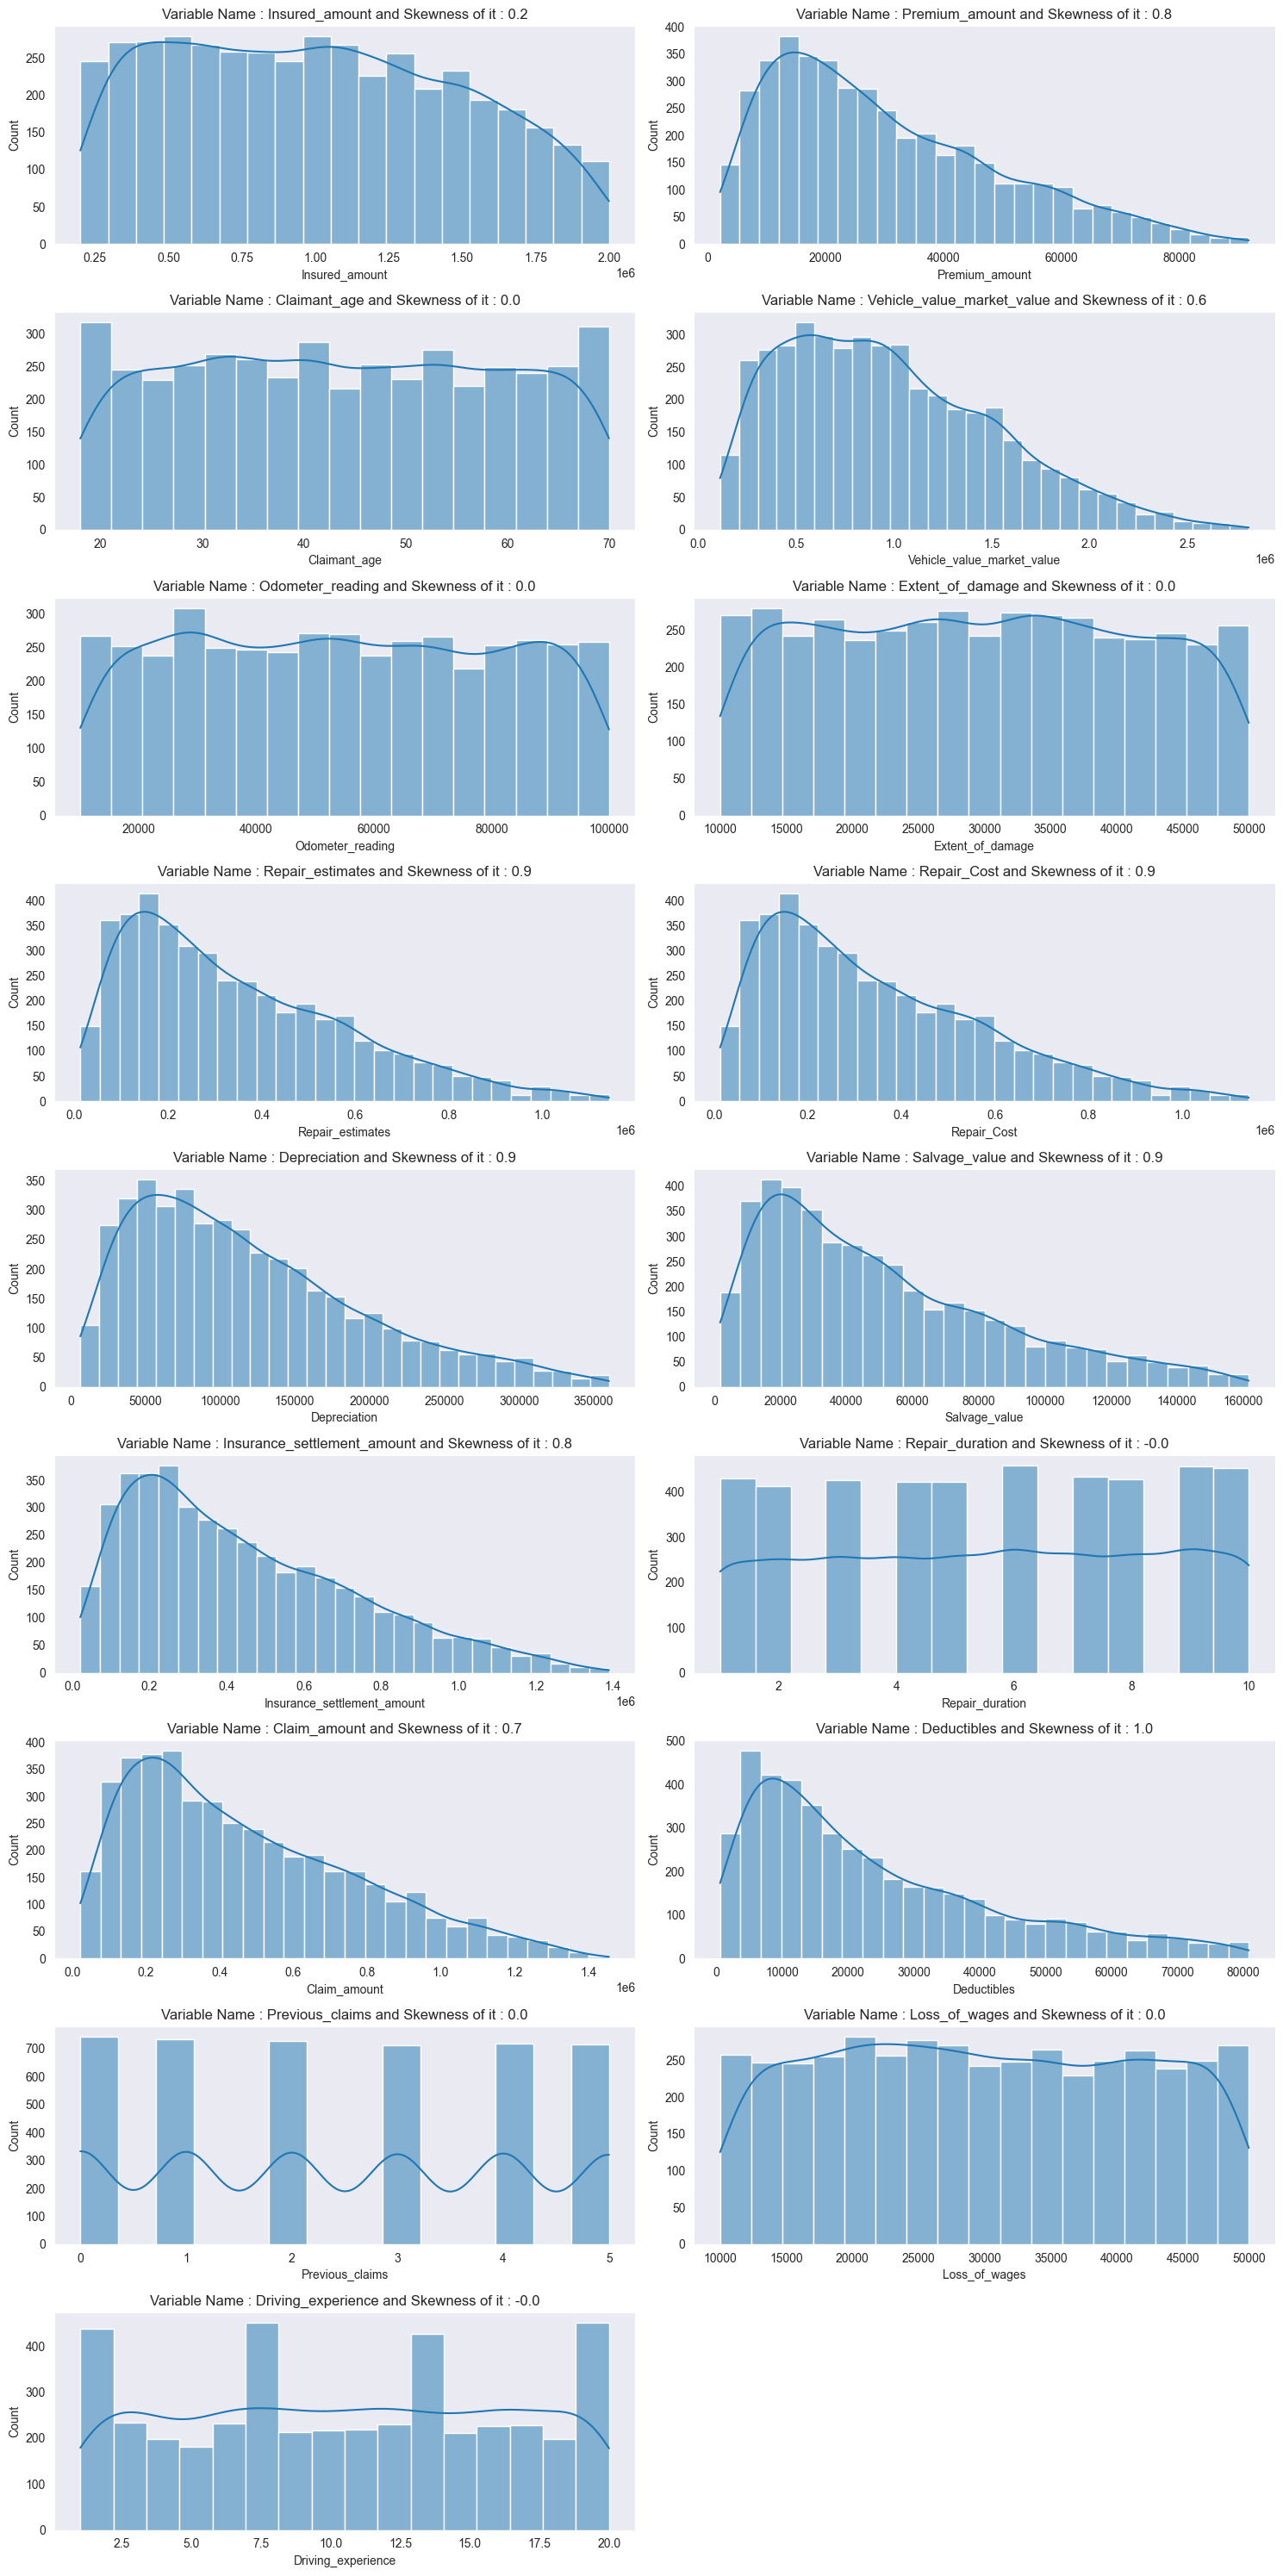

In [19]:
# Histogram
sns.set_style("dark") 
# Dropping the response variable "cost" column from the dataframe
cols = numerical_cols
print('Input variables :',cols)
# Building plot for each variables 
#Create new figure with specific size so it allows for multiple subplots to be displayed without overlapping
plt.figure(figsize=(15, 30) )

for count, item in enumerate(cols, 1): 
    plt.subplot(9, 2, count) 
    sns.histplot(df_cleaned[item], kde=True)
    skewness = round(df_cleaned[item].skew(),1)
    plt.title(f"Variable Name : {item} and Skewness of it : {skewness}")

plt.tight_layout() 
plt.show() 

In [20]:
#Apply Standard scaler standardization on numerical attibutes
from sklearn.preprocessing import StandardScaler
list1 = numerical_columns
list1.remove('Claim_amount')
scaler=StandardScaler()
df_cleaned[list1] = scaler.fit_transform(df_cleaned[list1])
df_cleaned.describe()

,Insured_amount,Premium_amount,Claimant_age,Vehicle_value_market_value,Odometer_reading,Extent_of_damage,Repair_estimates,Repair_Cost,Depreciation,Salvage_value,Insurance_settlement_amount,Repair_duration,Claim_amount,Deductibles,Previous_claims,Loss_of_wages,Driving_experience
count,4.346000e+03,4346.000000,4346.00000,4.346000e+03,4346.000000,4346.000000,4.346000e+03,4.346000e+03,4.346000e+03,4.346000e+03,4.346000e+03,4346.000000,4.346000e+03,4.346000e+03,4346.000000,4346.000000,4346.000000
mean,1.004248e+06,0.000000,43.88081,9.155636e-17,54718.543488,29746.893925,1.389695e-16,1.389695e-16,-9.809610e-18,-6.376246e-17,-6.049259e-17,5.568799,4.708047e+05,5.313539e-17,2.477911,29916.353889,10.530143
std,4.849714e+05,1.000115,15.19109,1.000115e+00,26047.139761,11509.283658,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,2.878512,3.071172e+05,1.000115e+00,1.711155,11514.759318,5.761995
min,2.001080e+05,-1.458484,18.00000,-1.598540e+00,10025.000000,10006.000000,-1.417350e+00,-1.417350e+00,-1.469698e+00,-1.348664e+00,-1.448084e+00,1.000000,2.189800e+04,-1.232624e+00,0.000000,10002.000000,1.000000
25%,5.865832e+05,-0.798175,31.00000,-7.970125e-01,31711.750000,19692.250000,-8.040144e-01,-8.040144e-01,-7.947470e-01,-8.047814e-01,-8.014523e-01,3.000000,2.236252e+05,-7.885949e-01,1.000000,20139.250000,6.000000
50%,9.869465e+05,-0.234743,44.00000,-1.508473e-01,54421.500000,29684.500000,-2.460661e-01,-2.460661e-01,-2.099155e-01,-2.486575e-01,-2.194419e-01,6.000000,4.008520e+05,-3.125503e-01,2.000000,29617.000000,11.000000
75%,1.393597e+06,0.638743,57.00000,6.791455e-01,77507.750000,39438.500000,6.396807e-01,6.396807e-01,5.872925e-01,6.151426e-01,6.464199e-01,8.000000,6.742605e+05,5.764603e-01,4.000000,39988.500000,16.000000
max,1.999703e+06,3.176417,70.00000,3.391120e+00,99990.000000,49998.000000,3.316683e+00,3.316683e+00,3.116832e+00,3.005442e+00,3.208425e+00,10.000000,1.456575e+06,2.955744e+00,5.000000,49992.000000,20.000000


In [21]:
df_cleaned.head(5)

,Type,Coverage,Coverage_Add_Ons,Policy_Status,Validity,Insured_amount,Premium_amount,Payment_status,Payment_Frequency,Policy_renewal_date,...,Final_settlement_approval,Claim_verification,Fraud_detection_approval,Driver_history,Driving_experience,Previous_traffic_violations,License_expiry_date,Alcohol_drug_test_results,License_class_if_applicable,License_Type
0,Car Insurance,Comprehensive,Road side assistance (24*7),Suspended,2024-12-12 to 2025-08-22,1788284,1.958701,Paid,Recurring,2025-12-20,...,True,True,True,Clean driving record,6,1 parking violation,2025-05-25,Passed,HGV,Permanent
1,Car Insurance,Third Party,No Claim Bonus,Cancelled,2024-04-04 to 2025-11-17,1268543,0.428941,Pending,Half Yearly,2025-12-09,...,False,True,False,Clean driving record,1,1 speeding,2027-01-28,Passed,LMV,Learning
2,Car Insurance,Accidental Coverage,Road side assistance (24*7),Effective,2025-02-06 to 2026-02-04,660740,-0.633967,Paid,Yearly,2025-07-27,...,True,True,False,One speeding ticket,15,1 speeding,2029-09-13,Failed,HGV,Learning
3,Car Insurance,Accidental Coverage,No Claim Bonus,Effective,2025-02-19 to 2026-02-14,1073115,0.552870,Paid,Quarterly,2026-06-19,...,True,False,True,One traffic violation,11,1 parking violation,2025-05-26,Failed,LMV,Learning
4,Car Insurance,Comprehensive,Road side assistance (24*7),Cancelled,2025-02-09 to 2025-12-18,592923,-1.096164,Pending,Quarterly,2026-03-23,...,False,False,True,2 minor accidents,11,1 parking violation,2026-09-20,Failed,LMV,Learning


# Vector encodding to convert categorical attributes to numerical

In [22]:
#!pip install pandas numpy tensorflow
#import pandas as pd
#import numpy as np
#import tensorflow as tf
#from sklearn.preprocessing import LabelEncoder
#from gensim.models import KeyedVectors


# Load GloVe vectors
#glove_vectors = KeyedVectors.load_word2vec_format('glove.6B.50d.txt', binary=False)

# Identify categorical attributes
#categorical_columns = ["Type", "Coverage", "Coverage_Add_Ons", "Policy_Status", "Payment_status", "Payment_Frequency", 
#                       "Claim_status","Vehicle_condition", "Vehicle_type_sedan_SUV_etc", "Claim_verification", "Fraud_detection_approval",
#                       "Fuel_type", "Insurance_coverage_type", "Nature_of_incident", "Incident_severity_level", "Driver_history",
#                       "Weather_conditions_at_the_time_of_the_accident", "Cause_of_incident", "License_class_if_applicable","Alcohol_drug_test_results", 
#                       "License_Type","Previous_traffic_violations","Driver_history", "Previous_traffic_violations"]

# Map categorical attributes to GloVe vectors
#def get_glove_vector(word):
#    try:
#        return glove_vectors[word]
#    except KeyError:
#        return np.zeros(glove_vectors.vector_size)

#glove_embeddings = {}
#for col in categorical_columns:
#    glove_embeddings[col] = np.array([get_glove_vector(str(val)) for val in df_cleaned[col].unique()])

# Create embedding layers using TensorFlow
#embedding_layers = {}
#for col in categorical_columns:
#    input_dim = len(df_cleaned[col].unique())
#    output_dim = glove_vectors.vector_size
#    embedding_layers[col] = tf.keras.layers.Embedding(input_dim=input_dim, output_dim=output_dim, weights=[glove_embeddings[col]], trainable=False)

# Create a simple model to train embeddings
#inputs = {col: tf.keras.layers.Input(shape=(1,), name=col) for col in categorical_columns}
#embeddings = {col: embedding_layers[col](inputs[col]) for col in categorical_columns}
#concatenated_embeddings = tf.keras.layers.Concatenate()(list(embeddings.values()))
#flattened_embeddings = tf.keras.layers.Flatten()(concatenated_embeddings)
#dense_layer = tf.keras.layers.Dense(128, activation='relu')(flattened_embeddings)
#output_layer = tf.keras.layers.Dense(1, activation='sigmoid')(dense_layer)

#model = tf.keras.Model(inputs=list(inputs.values()), outputs=output_layer)
#model.compile(optimizer='adam', loss='binary_crossentropy')

# Prepare the data for training
#X = {col: df_cleaned[col].values for col in categorical_columns}
#y = np.random.randint(0, 2, size=(df_cleaned.shape[0],))  # Dummy target variable for demonstration

# Train the model
#model.fit(X, y, epochs=5, batch_size=32)

# Extract embeddings
#embeddings_dict = {}
#for col in categorical_columns:
#    embeddings_dict[col] = embedding_layers[col].get_weights()[0]

# Example: Get embedding for a specific category
#example_category = df_cleaned["Type"].iloc[0]
#example_embedding = embeddings_dict["Type"][example_category]
#print(f"Embedding for category '{example_category}' in 'Type': {example_embedding}")

In [25]:
!pip install pandas numpy tensorflow
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder

# Identify categorical attributes
categorical_columns = ["Type", "Coverage", "Coverage_Add_Ons", "Policy_Status", "Payment_status", "Payment_Frequency", 
                       "Claim_status","Vehicle_condition", "Vehicle_type_sedan_SUV_etc", "Claim_verification", "Fraud_detection_approval",
                       "Fuel_type", "Insurance_coverage_type", "Nature_of_incident", "Driver_history",
                       "Weather_conditions_at_the_time_of_the_accident", "Cause_of_incident", "License_class_if_applicable","Alcohol_drug_test_results", 
                       "License_Type","Previous_traffic_violations","Driver_history", "Previous_traffic_violations"]

# Encode categorical attributes using LabelEncoder
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_cleaned[col] = le.fit_transform(df_cleaned[col])
    label_encoders[col] = le

# Define embedding dimensions
embedding_dims = {col: min(50, len(df[col].unique()) // 2) for col in categorical_columns}

# Create embedding layers using TensorFlow
embedding_layers = {}
for col in categorical_columns:
    input_dim = len(df_cleaned[col].unique())
    output_dim = embedding_dims[col]
    embedding_layers[col] = tf.keras.layers.Embedding(input_dim=input_dim, output_dim=output_dim)

# Create a simple model to train embeddings
inputs = {col: tf.keras.layers.Input(shape=(1,), name=col) for col in categorical_columns}
embeddings = {col: embedding_layers[col](inputs[col]) for col in categorical_columns}
concatenated_embeddings = tf.keras.layers.Concatenate()(list(embeddings.values()))
flattened_embeddings = tf.keras.layers.Flatten()(concatenated_embeddings)
dense_layer = tf.keras.layers.Dense(128, activation='relu')(flattened_embeddings)
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')(dense_layer)

model = tf.keras.Model(inputs=list(inputs.values()), outputs=output_layer)
model.compile(optimizer='adam', loss='binary_crossentropy')

# Prepare the data for training
X = {col: df_cleaned[col].values for col in categorical_columns}
y = np.random.randint(0, 2, size=(df_cleaned.shape[0],))  # Dummy target variable for demonstration

# Train the model
model.fit(X, y, epochs=5, batch_size=32)

# Extract embeddings
embeddings_dict = {}
for col in categorical_columns:
    embeddings_dict[col] = embedding_layers[col].get_weights()[0]

# Example: Get embedding for a specific category
example_category = df_cleaned["Type"].iloc[0]
example_embedding = embeddings_dict["Type"][example_category]
print(f"Embedding for category '{example_category}' in 'Type': {example_embedding}")

Defaulting to user installation because normal site-packages is not writeable
Epoch 1/5
136/136 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.6931
Epoch 2/5
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6924
Epoch 3/5
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6918
Epoch 4/5
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6887
Epoch 5/5
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6879
Embedding for category '0' in 'Type': []


In [26]:
df_cleaned.head(5)

,Type,Coverage,Coverage_Add_Ons,Policy_Status,Validity,Insured_amount,Premium_amount,Payment_status,Payment_Frequency,Policy_renewal_date,...,Final_settlement_approval,Claim_verification,Fraud_detection_approval,Driver_history,Driving_experience,Previous_traffic_violations,License_expiry_date,Alcohol_drug_test_results,License_class_if_applicable,License_Type
0,0,1,3,2,2024-12-12 to 2025-08-22,1788284,1.958701,0,3,2025-12-20,...,True,1,1,1,6,0,2025-05-25,1,0,1
1,0,2,2,0,2024-04-04 to 2025-11-17,1268543,0.428941,1,0,2025-12-09,...,False,1,0,1,1,1,2027-01-28,1,1,0
2,0,0,3,1,2025-02-06 to 2026-02-04,660740,-0.633967,0,4,2025-07-27,...,True,1,0,2,15,1,2029-09-13,0,0,0
3,0,0,2,1,2025-02-19 to 2026-02-14,1073115,0.552870,0,2,2026-06-19,...,True,0,1,3,11,0,2025-05-26,0,1,0
4,0,1,3,0,2025-02-09 to 2025-12-18,592923,-1.096164,1,2,2026-03-23,...,False,0,1,0,11,0,2026-09-20,0,1,0


 # Feature Creation

Use the insurance validity attribute to create a new continuous numeric attribute - number of days

In [27]:
from datetime import datetime

# Function to calculate the number of days from the current date to the end date
def calculate_days(validity):
    try:
        # Split the validity into start and end dates
        start_date, end_date = validity.split(' to ')
        
        # Convert the end date to a datetime object
        end_date = datetime.strptime(end_date, '%Y-%m-%d')
        
        # Get the current date
        current_date = datetime.now()
        
        # Calculate the number of days from current date to the end date
        return (end_date - current_date).days
    except Exception as e:
        print(f"Error processing validity: {validity}. Error: {e}")
        return None  # Handle invalid data by returning None or a default value

# Apply the function to the Validity column
df_cleaned['Validity_days'] = df_cleaned['Validity'].apply(calculate_days)

# Display the DataFrame
print(df_cleaned['Validity_days'])


0       125
1       212
2       291
3       301
4       243
       ... 
4995    265
4996     87
4997    199
4998    305
4999    252
Name: Validity_days, Length: 4346, dtype: int64


In [28]:
# Convert license expiry date to number of days to expiry

In [29]:
# Convert 'License_expiry_date' to datetime
df_cleaned['License_expiry_date'] = pd.to_datetime(df_cleaned['License_expiry_date'])

# Calculate the number of days until expiry
current_date = datetime.now()
df_cleaned['License_expire_days'] = (df_cleaned['License_expiry_date'] - current_date).dt.days

df_cleaned = df_cleaned.drop(['License_expiry_date'], axis=1)
print(df_cleaned)

      Type  Coverage  Coverage_Add_Ons  Policy_Status  \
0        0         1                 3              2   
1        0         2                 2              0   
2        0         0                 3              1   
3        0         0                 2              1   
4        0         1                 3              0   
...    ...       ...               ...            ...   
4995     0         2                 3              2   
4996     0         2                 2              1   
4997     0         2                 4              1   
4998     0         1                 4              2   
4999     0         1                 4              2   

                      Validity  Insured_amount  Premium_amount  \
0     2024-12-12 to 2025-08-22         1788284        1.958701   
1     2024-04-04 to 2025-11-17         1268543        0.428941   
2     2025-02-06 to 2026-02-04          660740       -0.633967   
3     2025-02-19 to 2026-02-14         1073115     

In [30]:
# Convert 'Policy_renewal_date' to datetime
df_cleaned['Policy_renewal_date'] = pd.to_datetime(df_cleaned['Policy_renewal_date'])

current_date = datetime.now()
df_cleaned['Policy_renewal_days'] = (df_cleaned['Policy_renewal_date'] - current_date).dt.days

df_cleaned = df_cleaned.drop(['Policy_renewal_date'], axis=1)
print(df_cleaned)

      Type  Coverage  Coverage_Add_Ons  Policy_Status  \
0        0         1                 3              2   
1        0         2                 2              0   
2        0         0                 3              1   
3        0         0                 2              1   
4        0         1                 3              0   
...    ...       ...               ...            ...   
4995     0         2                 3              2   
4996     0         2                 2              1   
4997     0         2                 4              1   
4998     0         1                 4              2   
4999     0         1                 4              2   

                      Validity  Insured_amount  Premium_amount  \
0     2024-12-12 to 2025-08-22         1788284        1.958701   
1     2024-04-04 to 2025-11-17         1268543        0.428941   
2     2025-02-06 to 2026-02-04          660740       -0.633967   
3     2025-02-19 to 2026-02-14         1073115     

Drop validity attribute as we added Number of days attribute

In [31]:
df_cleaned = df_cleaned.drop(['Validity'], axis=1)

In [32]:
df_cleaned.shape

(4346, 58)

# Bivariate Analysis - Claim amount vs numeric attributes

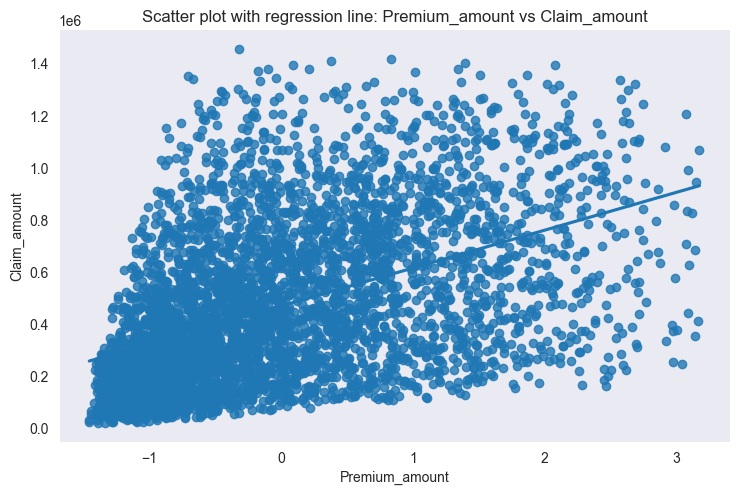

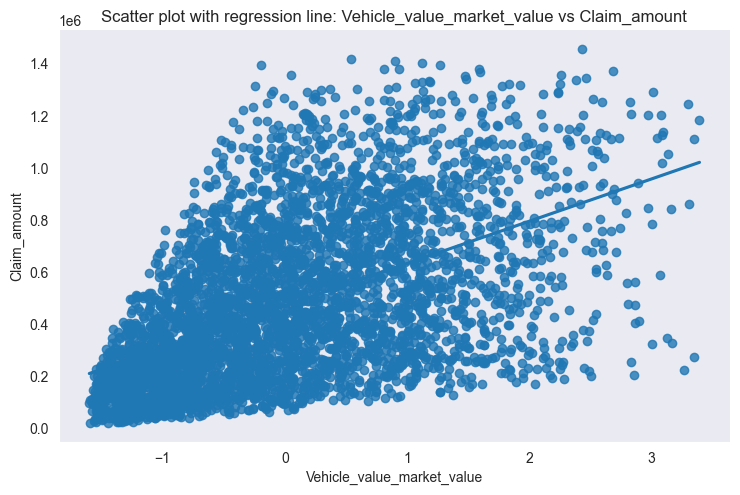

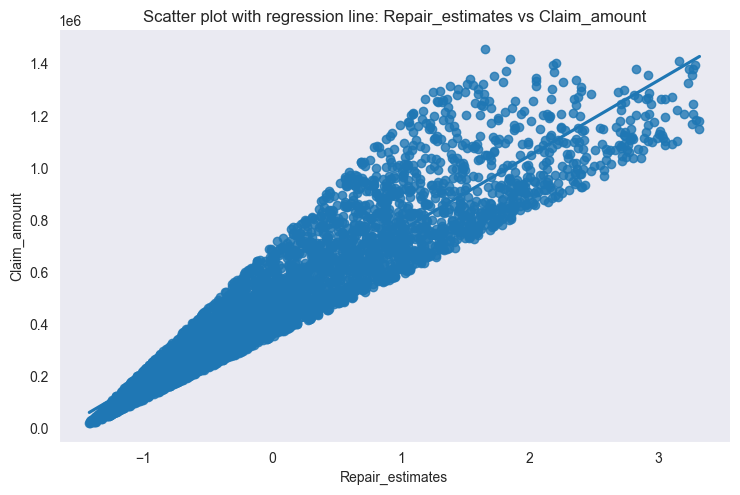

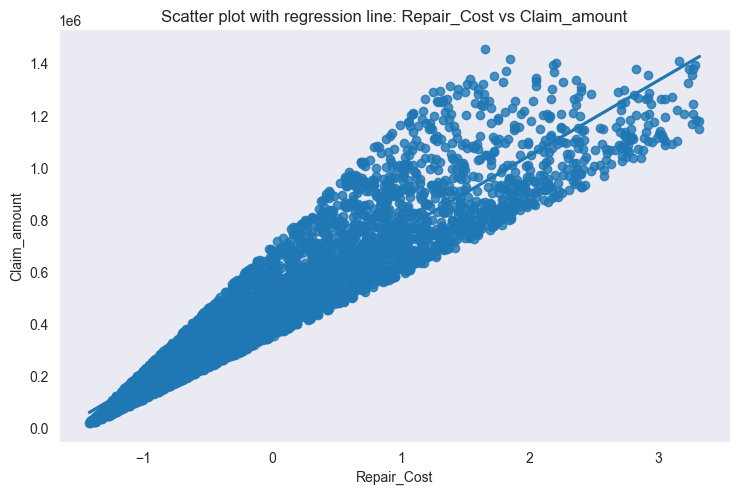

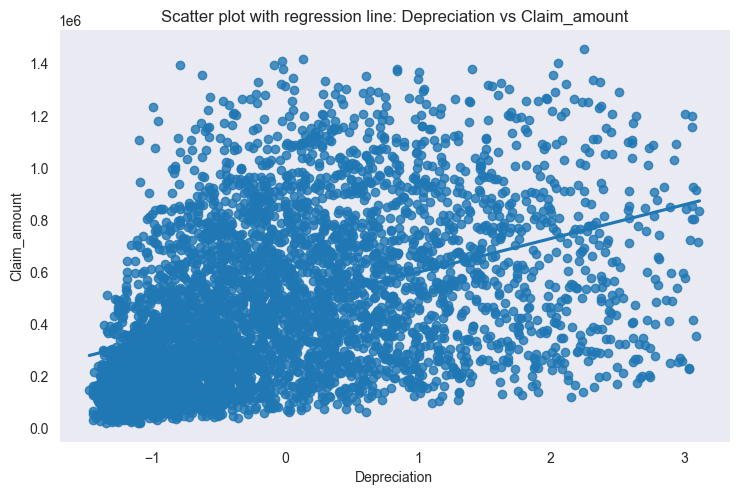

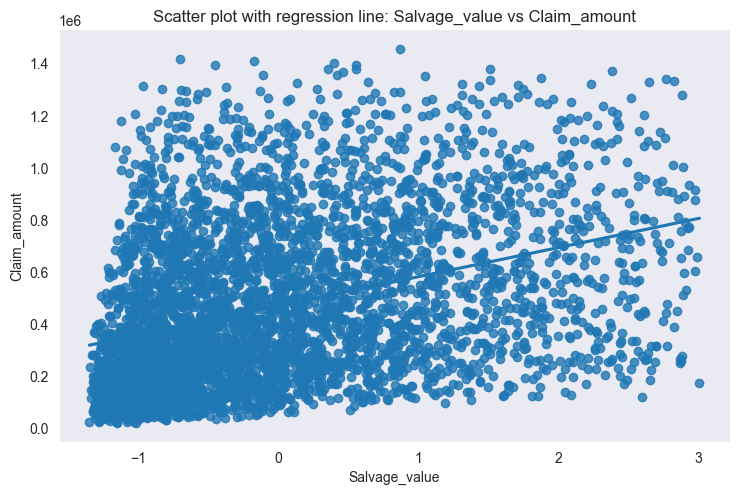

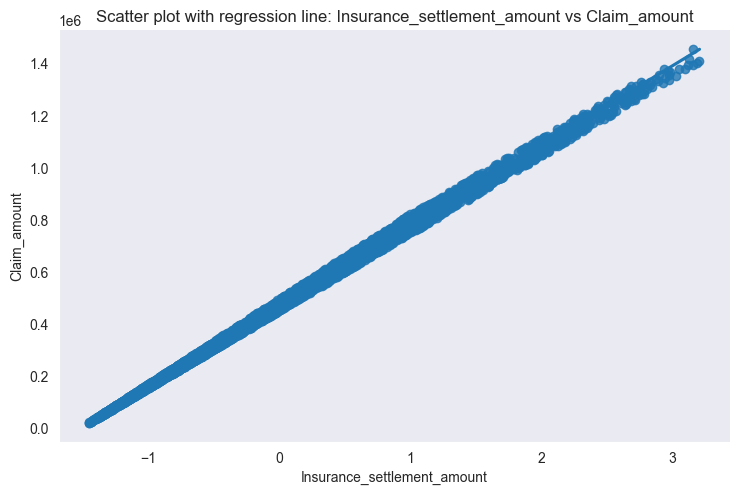

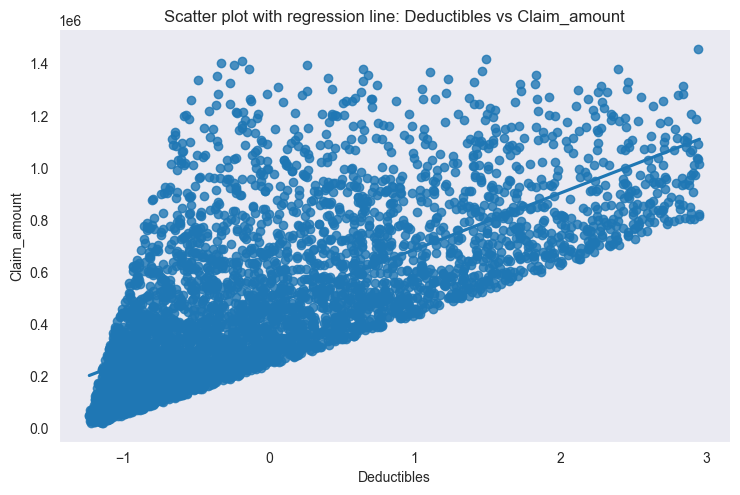

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

# List of independent variables
independent_vars = ['Premium_amount', 'Vehicle_value_market_value', 'Repair_estimates', 'Repair_Cost', 'Depreciation', 'Salvage_value', 'Insurance_settlement_amount', 'Deductibles']

# Target variable
target_var = 'Claim_amount'

# Function to plot scatter plot with regression line
def plot_scatter_with_regression(df_cleaned, x_var, y_var):
    sns.lmplot(x=x_var, y=y_var, data=df_cleaned, aspect=1.5, ci=None)
    plt.title(f'Scatter plot with regression line: {x_var} vs {y_var}')
    plt.xlabel(x_var)
    plt.ylabel(y_var)
    plt.show()

# Generate scatter plots with regression lines for each independent variable
for var in independent_vars:
    plot_scatter_with_regression(df_cleaned, var, target_var)


# Multivariate Analysis - Pearson Correaltion HeatMap

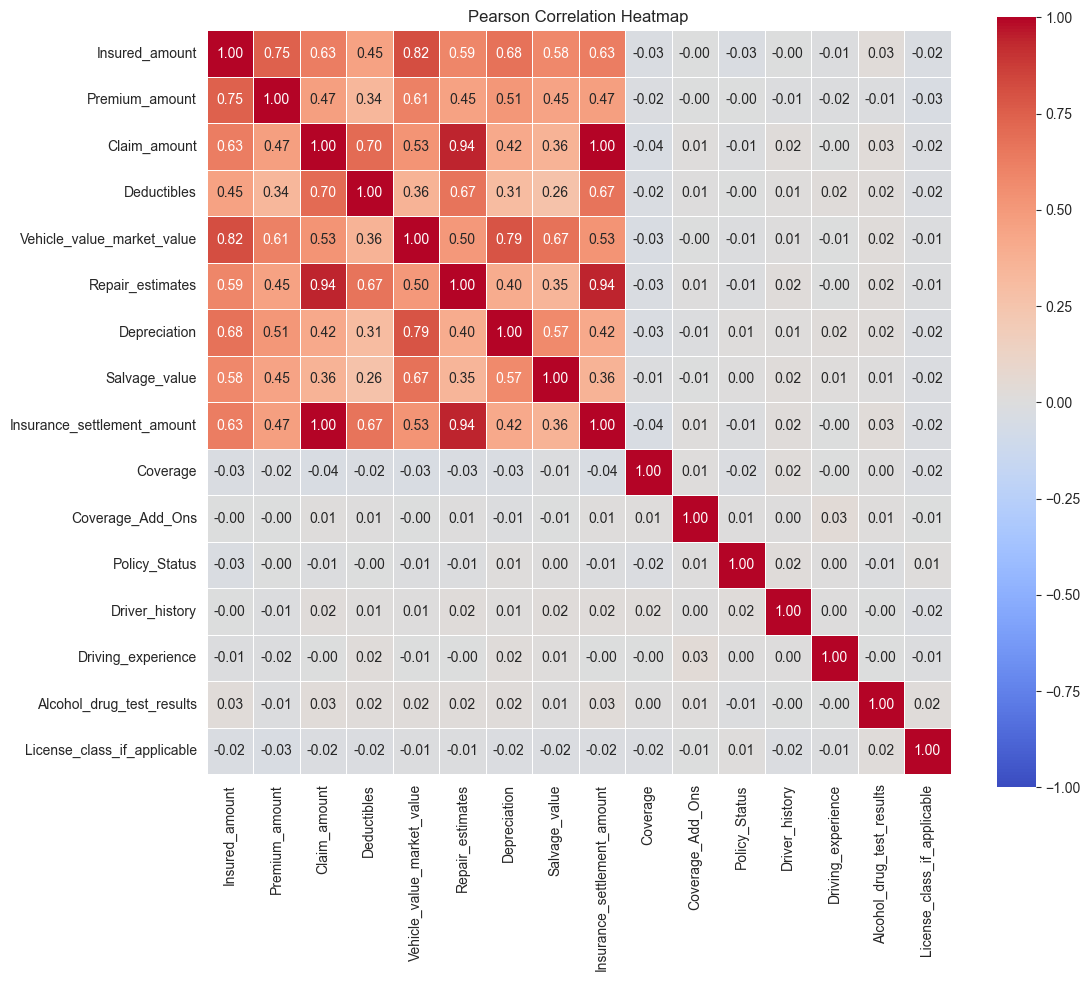

In [34]:
# Calculate Pearson correlation matrix
# List of numeric attributes
numeric_attributes = [
    "Insured_amount", "Premium_amount", "Claim_amount", "Deductibles", 
    "Vehicle_value_market_value", "Repair_estimates", "Depreciation", 
    "Salvage_value", "Insurance_settlement_amount", "Coverage", 
    "Coverage_Add_Ons", "Policy_Status", "Driver_history", 
    "Driving_experience", "Alcohol_drug_test_results", "License_class_if_applicable"
]

# Calculate the Pearson correlation matrix
correlation_matrix = df_cleaned[numeric_attributes].corr(method='pearson')

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=.5)

# Set the title
plt.title('Pearson Correlation Heatmap')

# Show the plot
plt.show()

# Dataset Summary - Pandas Profiling

In [35]:
#import pandas as pd
#from ydata_profiling import ProfileReport  # pandas-profiling is now ydata-profiling
#import warnings
#from pandas.errors import PerformanceWarning
 
# Generate profile report
#profile = ProfileReport(df_cleaned, explorative=True)
 
# Save report as an interactive HTML file
#profile.to_file("pandas_profiling_report.html")
 
# Display in Jupyter Notebook (Optional)
#profile.to_notebook_iframe()

# Train-Test Split

In [36]:
from sklearn.model_selection import train_test_split
X = df_cleaned.drop('Claim_amount', axis=1)  # Replace 'target' with your actual target column name
y = df_cleaned['Claim_amount']

# Split the data into train, cross-validation, and test sets
# Test sample size = 1000 Cross validation sample size = 200
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=1000, random_state=42)
X_cv, X_test, y_cv, y_test = train_test_split(X_temp, y_temp, test_size=800, random_state=42)
X_train = X_train.select_dtypes(exclude=['object'])
X_cv = X_cv.select_dtypes(exclude=['object'])
X_test = X_test.select_dtypes(exclude=['object'])

In [37]:
print("Cross validation size:", X_cv.shape)
print("Test sample size:", X_test.shape)

Cross validation size: (200, 47)
Test sample size: (800, 47)


# Linear Regression Model

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Linear Regression model
model_LR = LinearRegression()

# Train the model on the training data
model_LR.fit(X_train, y_train)

# Optionally, print the coefficients
print('Coefficients:', model_LR.coef_)
print('Intercept:', model_LR.intercept_)

# Predict on the test data
y_test_pred = model_LR.predict(X_test)

#Predict on the validation set
y_cv_pred = model_LR.predict(X_cv)


# Evaluate the model on test data
mse_test = mean_squared_error(y_test, y_test_pred)
print(f'Test Mean Squared Error: {mse_test}')
r2_test = r2_score(y_test, y_test_pred)
print(f"Test R^2 Score: {r2_test}")

# Calculate and print the mean squared error and R^2 score for validation set
mse_cv = mean_squared_error(y_cv, y_cv_pred)
print(f"Validation Mean Squared Error: {mse_cv}")
r2_cv = r2_score(y_cv, y_cv_pred)
print(f"Validation R^2 Score: {r2_cv}")

Coefficients: [ 4.52528093e-07  3.66679465e-11  2.55796728e-11  3.69007615e-11
 -1.74283250e-15  3.25209945e-11 -2.86386764e-11  2.40510813e-11
 -3.26440805e-12  7.66835298e-11  7.23459074e-11 -1.20275831e-12
  4.03333454e-11  1.79926445e-12 -1.38976877e-15 -2.73583616e-11
  1.19443231e-10  1.46830118e-11  9.18609408e-11 -7.55863474e-12
 -2.79498787e-11  1.04283428e-14  1.18213098e-10 -1.08819517e-10
  5.42311134e-11  5.08653438e-11  2.93897670e+05 -2.08066193e-11
  1.91625953e+04  9.83065152e-12  1.70710125e-11  4.81653069e-11
 -4.93506061e-14 -5.94632565e-11 -3.68786682e-11 -6.08951722e-11
 -4.01746453e-11 -7.15840701e-11 -5.54933663e-11  7.89391768e-12
 -6.10632600e-11 -4.00146034e-11  5.94229490e-11 -3.39146572e-11
 -1.52166525e-12  3.88162057e-13 -3.61701537e-13]
Intercept: 470804.726645194
Test Mean Squared Error: 1.1145143052941837e-18
Test R^2 Score: 1.0
Validation Mean Squared Error: 1.2027698444421614e-18
Validation R^2 Score: 1.0


## Exposing Linear regression Model to API Endpoint

In [39]:
import joblib 
# joblib is a Python library designed for efficient serialization and parallel computing, 
# particularly useful when working with large datasets or scikit-learn models.
joblib.dump(model_LR,"claim_pred_Linear_Regression.joblib")

['claim_pred_Linear_Regression.joblib']

In [40]:
saved__model_LR=joblib.load("claim_pred_Linear_Regression.joblib")
saved__model_LR

LinearRegression()

In [41]:
new_input = pd.DataFrame(data=dict(
    Type=[0],
    Coverage=[2],
    Coverage_Add_Ons=[3],
    Policy_Status=[0],
    Insured_amount=[361179],
    Premium_amount=[-1.156421],
    Payment_status=[0],
    Payment_Frequency=[1],
    Claimant_age=[25],
    Vehicle_condition=[1],
    Vehicle_value_market_value=[-1.454529],
    Vehicle_type_sedan_SUV_etc=[2],
    Fuel_type=[1],
    Insurance_coverage_type=[0],
    Odometer_reading=[23968],
    Nature_of_incident=[0],
    Weather_conditions_at_the_time_of_the_accident=[1],
    Cause_of_incident=[3],
    Own_Damage=[True],
    Third_Party=[False],
    Comprehensive=[False],
    Extent_of_damage=[11335],
    Repair_estimates=[-0.918854],
    Repair_Cost=[-0.918854],
    Depreciation=[-1.258181],
    Salvage_value=[-1.225156],
    Insurance_settlement_amount=[-0.748663],
    Repair_duration=[2],
    Deductibles=[-0.461538],
    Previous_claims=[2],
    Claim_status=[2],
    Disability_status=[True],
    Loss_of_wages=[27637],
    Red_flags=[False],
    Court_cases=[False],
    Final_settlement_approval=[False],
    Claim_verification=[0],
    Fraud_detection_approval=[0],
    Driver_history=[2],
    Driving_experience=[8],
    Previous_traffic_violations=[1],
    Alcohol_drug_test_results=[0],
    License_class_if_applicable=[1],
    License_Type=[0],
    Validity_days=[43],
    License_expire_days=[1352],
    Policy_renewal_days=[525]
))


In [42]:
saved__model_LR.predict(new_input)[0]

np.float64(241930.14931726898)

# Deep Learning Implementation

Implementation using keras

In [43]:
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from keras.models import Sequential
from keras.layers import Dense


# Define the deep learning model
model_DL = Sequential()
model_DL.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model_DL.add(Dense(32, activation='relu'))
model_DL.add(Dense(1, activation='linear'))

# Compile the model
model_DL.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model_DL.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_cv, y_cv))

# Make predictions on the validation set
y_cv_pred = model_DL.predict(X_cv)
mse_cv = mean_squared_error(y_cv, y_cv_pred)
r2_cv = r2_score(y_cv, y_cv_pred)

print(f"Validation Mean Squared Error: {mse_cv}")
print(f"Validation R^2 Score: {r2_cv}")

# Make predictions on the test set
y_test_pred = model_DL.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Test Mean Squared Error: {mse_test}")
print(f"Test R^2 Score: {r2_test}")

Epoch 1/100


C:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 154064420864.0000 - val_loss: 58280828928.0000
Epoch 2/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 56348405760.0000 - val_loss: 58341965824.0000
Epoch 3/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 55815593984.0000 - val_loss: 58363666432.0000
Epoch 4/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 55761543168.0000 - val_loss: 58728144896.0000
Epoch 5/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 57409466368.0000 - val_loss: 58562273280.0000
Epoch 6/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 56690630656.0000 - val_loss: 58420588544.0000
Epoch 7/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 56378478592.0000 - val_loss: 58496663552.0000
Epoch 8/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 58022416384.0000 - val_loss: 58421305344.0000
Epoch 9/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 57003831296.0000 - val_loss: 59855634432.0000
Epoch 10/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms

## Exposing Deep Learninig Model to API Endpoint

In [44]:
import joblib 
# joblib is a Python library designed for efficient serialization and parallel computing, 
# particularly useful when working with large datasets or scikit-learn models.
joblib.dump(model_DL,"claim_pred_Deep_Learning.joblib")

['claim_pred_Deep_Learning.joblib']

In [45]:
saved__model_DL=joblib.load("claim_pred_Deep_Learning.joblib")
saved__model_DL

<Sequential name=sequential, built=True>

In [46]:
saved__model_DL.predict(new_input)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


array([176167.39], dtype=float32)

Implementation using Tensor flow

In [47]:
import tensorflow as tf
# Define the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(X_train.shape[1],))
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=100, validation_data=(X_cv, y_cv))

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Root Mean Squared Error: {rmse}')

Epoch 1/100


C:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 726628368384.0000 - val_loss: 565910700032.0000
Epoch 2/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 546133999616.0000 - val_loss: 421337497600.0000
Epoch 3/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 402313707520.0000 - val_loss: 311758290944.0000
Epoch 4/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 296465465344.0000 - val_loss: 229558140928.0000
Epoch 5/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 214801956864.0000 - val_loss: 170895278080.0000
Epoch 6/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 165400870912.0000 - val_loss: 130023530496.0000
Epoch 7/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 116050157568.0000 - val_loss: 102388891648.0000
Epoch 8/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 96594075648.0000 - val_loss: 84866482176.0000
Epoch 9/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 79094538240.0000 - val_loss: 73999081472.0000
Epoch 10/100
105/105 ━━━━━━━━━━━━━━

# CNN

In [48]:
df_cleaned.head(5)

,Type,Coverage,Coverage_Add_Ons,Policy_Status,Insured_amount,Premium_amount,Payment_status,Payment_Frequency,Claimant_age,Vehicle_condition,...,Fraud_detection_approval,Driver_history,Driving_experience,Previous_traffic_violations,Alcohol_drug_test_results,License_class_if_applicable,License_Type,Validity_days,License_expire_days,Policy_renewal_days
0,0,1,3,2,1788284,1.958701,0,3,67,1,...,1,1,6,0,1,0,1,125,36,245
1,0,2,2,0,1268543,0.428941,1,0,31,0,...,0,1,1,1,1,1,0,212,649,234
2,0,0,3,1,660740,-0.633967,0,4,36,0,...,0,2,15,1,0,0,0,291,1608,99
3,0,0,2,1,1073115,0.552870,0,2,25,1,...,1,3,11,0,0,1,0,301,37,426
4,0,1,3,0,592923,-1.096164,1,2,21,1,...,1,0,11,0,0,1,0,243,519,338


CNN

Dropped temporarily - convert them to numeric via labeling

In [49]:
df_cleaned = df_cleaned.drop(['Traffic_condition_at_the_time_of_incident'], axis=1)
df_cleaned = df_cleaned.drop(['Incident_description'], axis=1)
df_cleaned = df_cleaned.drop(['Involvement_of_pedestrians_or_animals'], axis=1)
df_cleaned = df_cleaned.drop(['Damage_to_property_outside_the_vehicle'], axis=1)
df_cleaned = df_cleaned.drop(['Parts_replaced'], axis=1)
df_cleaned = df_cleaned.drop(['Driving_License'], axis=1)
df_cleaned = df_cleaned.drop(['Investigation'], axis=1)
df_cleaned = df_cleaned.drop(['Regulatory_compliance'], axis=1)
df_cleaned = df_cleaned.drop(['Fraud_detection'], axis=1)
df_cleaned = df_cleaned.drop(['Claims_approval_status'], axis=1)

In [50]:
df_cleaned.shape

(4346, 48)

In [51]:
object_cols = df_cleaned.select_dtypes(include=['object'])
print(object_cols)

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 8, 9, 11, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 34, 35, 37, 38, 41, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 64, 65, 66, 67, 68, 70, 71, 72, 73, 74, 75, 76, 77, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 91, 92, 93, 94, 95, 96, 97, 98, 99, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, ...]

[4346 rows x 0 columns]


In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten


# Assuming df has features and 'claim_amount' as the target column
features = df_cleaned.drop(columns=['Claim_amount'])
target = df_cleaned['Claim_amount']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for Conv1D (samples, time steps, features)
X_train_scaled = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Build the CNN model
model_CNN = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train_scaled.shape[1], 1)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1)  # Output layer for regression
])

model_CNN.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model_CNN.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2)

# Evaluate the model
loss = model_CNN.evaluate(X_test_scaled, y_test)
print(f'Test Loss: {loss}')

# Predict claim amounts
y_pred = model_CNN.predict(X_test_scaled)
#print(y_pred)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Root Mean Squared Error: {rmse}')

Epoch 1/50


C:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 305219502080.0000 - val_loss: 337450598400.0000
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 307352338432.0000 - val_loss: 333888880640.0000
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 299576557568.0000 - val_loss: 323507978240.0000
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 295329431552.0000 - val_loss: 303621439488.0000
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 280061968384.0000 - val_loss: 273373642752.0000
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 236045205504.0000 - val_loss: 234786193408.0000
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 195139403776.0000 - val_loss: 192494780416.0000
Epoch 8/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 162638004224.0000 - val_loss: 153216876544.0000
Epoch 9/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 133139808256.0000 - val_loss: 122475823104.0000
Epoch 10/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss

# Implementation using hugging face library

To implement the regression model using Hugging Face's transformers library, we will use the Trainer API along with a custom model.
This code defines a custom regression model using PyTorch, converts the data to the Hugging Face Dataset format, sets up the Trainer with appropriate training arguments, and evaluates the model on both validation and test sets.

# XGBoost Implementation

In [53]:
!pip install xgboost
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Create and train the model
model_XGB = xgb.XGBRegressor(objective='reg:squarederror')
model_XGB.fit(X_train, y_train)

# Predict and evaluate
y_pred = model_XGB.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")


Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.0.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached scipy-1.15.2-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached xgboost-3.0.0-py3-none-win_amd64.whl (150.0 MB)
Using cached scipy-1.15.2-cp312-cp312-win_amd64.whl (40.9 MB)
Mean Squared Error: 25322496.0


## Exposing XGBoost Model to API Endpoint

In [54]:
import joblib 
# joblib is a Python library designed for efficient serialization and parallel computing, 
# particularly useful when working with large datasets or scikit-learn models.
joblib.dump(model_XGB,"claim_pred_XGBOOST.joblib")

['claim_pred_XGBOOST.joblib']

In [55]:
saved__model_XGB=joblib.load("claim_pred_XGBOOST.joblib")
saved__model_XGB

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [56]:
saved__model_XGB.predict(new_input)[0]

np.float32(241787.3)